<a href="https://colab.research.google.com/github/amine-banani/Deep-Learning-Framework-for-Multi-Organ-Semantic-Segmentation/blob/main/atelier_ia_cadarache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/amine-banani/atelier-ia-images.git
%cd atelier-ia-images

Cloning into 'atelier-ia-images'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 4.13 MiB | 16.59 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/kaggle/working/atelier-ia-images


In [ ]:
IMAGE_PATH = "maria-sime-349-eXDixFE-unsplash.jpg"

# Comment une IA voit-elle une image ?

Prenez quelques secondes.

**Qu’est-ce que vous voyez ?**

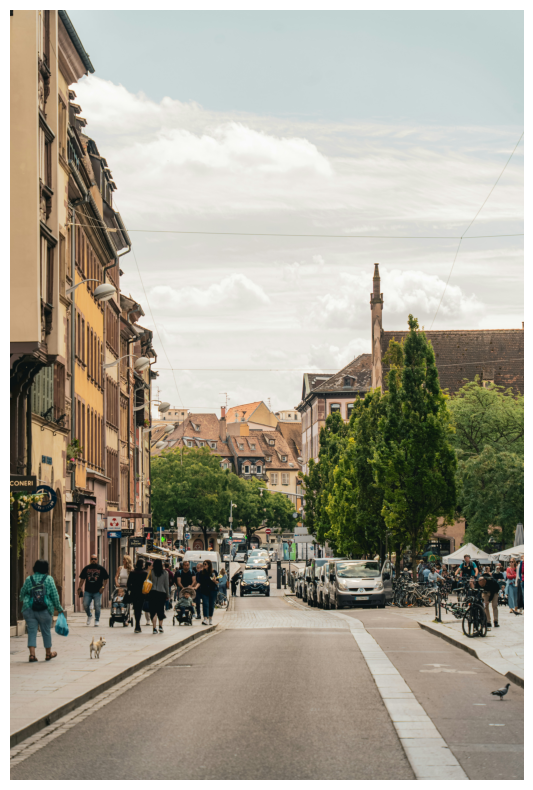

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

## Et au-delà des objets ?

**Qu’est-ce que vous comprenez de la scène ?**

---

Nous venons de reconnaître des objets, des relations et un contexte.

Mais l’ordinateur, lui, ne reçoit rien de tout cela directement.

**Alors, qu’est-ce qu’il reçoit réellement ?**

In [ ]:
import numpy as np

arr = np.array(image)

print("Taille de l'image :", arr.shape)
print("Type des valeurs :", arr.dtype)
print("Exemple d'un pixel RGB :", arr[200, 300])

Taille de l'image : (7008, 4672, 3)
Type des valeurs : uint8
Exemple d'un pixel RGB : [172 141 113]


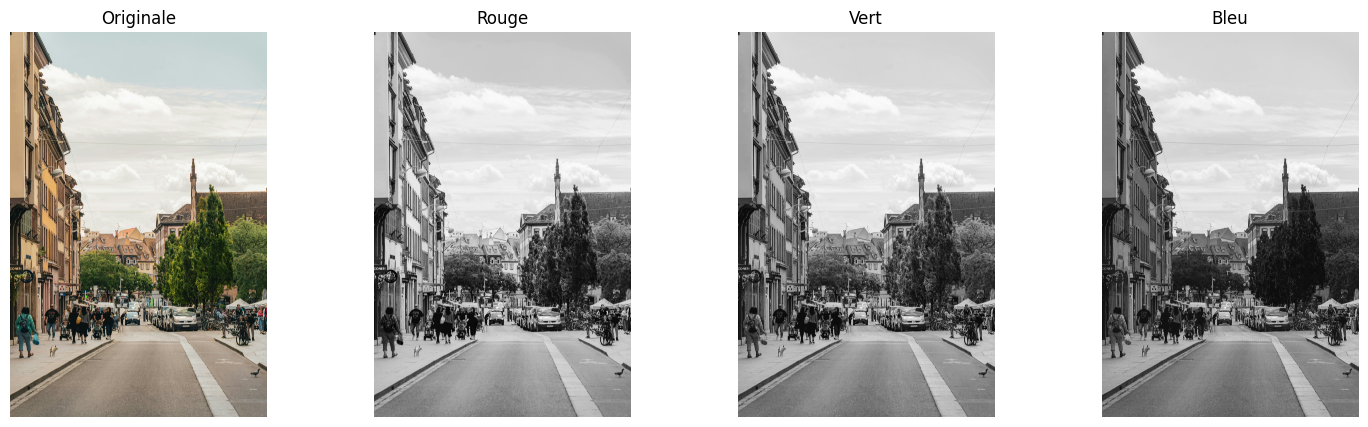

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(arr)
axes[0].set_title("Originale")

for i, name in enumerate(["Rouge", "Vert", "Bleu"]):
    channel = arr[:, :, i]
    axes[i + 1].imshow(channel, cmap="gray")
    axes[i + 1].set_title(name)

for ax in axes:
    ax.axis("off")

plt.show()

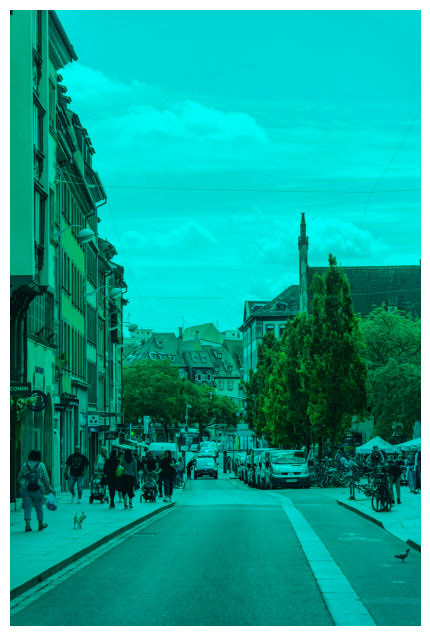

In [ ]:
def remove_channel(image_array, channel):
    out = image_array.copy()
    idx = {"red": 0, "green": 1, "blue": 2}[channel]
    out[:, :, idx] = 0
    return out

modified = remove_channel(arr, "red")

plt.figure(figsize=(14, 8))
plt.imshow(modified)
plt.axis("off")
plt.show()